### Загрузка и анализ структуры SQuAD 1.1

SQuAD датасет состоит из тем (статей), параграфов (контекстов) и вопросов с ответами. Каждый ответ содержит текст и позицию начала в контексте.

In [ ]:
import json

with open('/content/train-v1.1.json', 'r') as f1, open('/content/dev-v1.1.json', 'r') as f2:
  train_data=json.load(f1)
  val_data=json.load(f2)

print(train_data.keys())
print(f'тем: {len(train_data['data'])}')
print(f'тема: {train_data['data'][0]['title']}')
print(f'параграфов в теме: {len(train_data['data'][0]['paragraphs'])}')

first_paragraph = train_data["data"][0]["paragraphs"][0]  #первый параграф
first_qas = first_paragraph["qas"][0]  # первый вопрос-ответ

print(f'\nконтекст: {first_paragraph['context'][:200]}...')
print(f'\nвопрос: {first_qas['question']}')
print(f'ответ: {first_qas['answers'][0]['text']}')
print(f'позиция ответа: {first_qas['answers'][0]['answer_start']}')

dict_keys(['data', 'version'])
тем: 442
тема: University_of_Notre_Dame
параграфов в теме: 55

контекст: Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper sta...

вопрос: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
ответ: Saint Bernadette Soubirous
позиция ответа: 515


In [ ]:
from transformers import BertTokenizer
import torch

tokenizer=BertTokenizer.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

### Класс QuestionDataset (валидация ответов + фильтрация)
Проверяем, что позиция ответа соответствует контексту после токенизации BERT. `is_valid()` использует `offset_mapping`, чтобы найти start/end токены.

In [ ]:
class QuestionDataset():
  def __init__(self, data, max_examples=None, max_len=384):
    self.examples=[]
    k=0
    for art in data['data']:
      for p in art['paragraphs']:
        for q in p['qas']:
          if q['answers']:
            for ans in q['answers']:
              if self.is_valid(p['context'], q['question'],ans['text'],ans['answer_start'], tokenizer, max_len):
                self.examples.append({
                    'context':p['context'],
                    'question':q['question'],
                    'answer':ans['text'],
                    'answer_start':ans['answer_start']
                })
                k+=1
                if max_examples and k>=max_examples:
                  return
  def is_valid(self,context, question, answer, answer_start, tokenizer,max_len):
    inputs=tokenizer(question, context, max_length=max_len,truncation='only_second', return_offsets_mapping=True)
    answer_end=answer_start+len(answer)
    offset_mapping=inputs['offset_mapping']

    start_token=None
    end_token=None

    for j, (start_char,end_char) in enumerate(offset_mapping):
      if start_char==0 and end_char==0:
        continue
      if start_char<=answer_start<end_char:
        start_token=j
      if start_char<answer_end<=end_char:
        end_token=j
        break
    return start_token is not None and end_token is not None

  def __len__(self):
    return len(self.examples)

  def __getitem__(self,i):
    return self.examples[i]

In [ ]:
train_dataset=QuestionDataset(train_data, max_examples=5000)
val_dataset=QuestionDataset(val_data, max_examples=1000)

print(f'train: {len(train_dataset)}')
print(f'val: {len(val_dataset)}')

train: 5000
val: 1000


### Батчевая токенизация (динамическое вычисление позиций ответа)
Для каждого примера в батче заново вычисляем `start_positions` и `end_positions` на основе `offset_mapping`.

In [ ]:
def batch_tokenizer(batch):
  contexts=[el['context'] for el in batch]
  questions=[el['question'] for el in batch]
  answers=[el['answer'] for el in batch]
  answer_starts=[el['answer_start'] for el in batch]

  inputs=tokenizer(questions,contexts,max_len=384, padding=True,
                   truncation='only_second', return_tensors='pt', return_offsets_mapping=True)

  start_positions=[]
  end_positions=[]

  for i, (offset_mapping, answer_start, answer) in enumerate(zip(inputs['offset_mapping'],answer_starts, answers)):
    answer_end=answer_start+len(answer)

    start_token=None
    end_token=None

    for j, (start_char, end_char) in enumerate(offset_mapping):
      if start_char==0 and end_char==0:
        continue
      if start_char<=answer_start<end_char:
        start_token=j
      if start_char< answer_end <=end_char:
        end_token=j
        break
    start_positions.append(start_token)
    end_positions.append(end_token)

  inputs.pop('offset_mapping')
  return {
      'input_ids':inputs['input_ids'],
      'attention_mask':inputs['attention_mask'],
      'token_type_ids': inputs['token_type_ids'],
      'start_positions': torch.tensor(start_positions),
      'end_positions': torch.tensor(end_positions)
      }

In [ ]:
from torch.utils.data import DataLoader

train_loader=DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=batch_tokenizer)
val_loader=DataLoader(val_dataset, batch_size=16, shuffle=False, collate_fn=batch_tokenizer)

print(f'train батчей: {len(train_loader)}')
print(f'val батчей: {len(val_loader)}')

train батчей: 313
val батчей: 63


### Обучение BERT для Question Answering
- Модель: `BertForQuestionAnswering`
- Оптимизатор: Adam, lr=1e-5
- Метрика: точность совпадения (оба токена - start и end)
- Сохраняется лучшая модель по validation loss

In [ ]:
from transformers import BertForQuestionAnswering
from torch.nn import CrossEntropyLoss
from torch import optim

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_bert=BertForQuestionAnswering.from_pretrained('bert-base-uncased').to(device)
optimizer_bert=optim.Adam(model_bert.parameters(), lr=1e-5)

best_val_loss = float('inf')
best_val_acc = 0
best_epoch = 0

for epoch in range(3):
  model_bert.train()
  train_loss=0
  train_cor=0
  train_tot=0

  for batch in train_loader:
    input_ids=batch['input_ids'].to(device)
    attention_mask=batch['attention_mask'].to(device)
    token_type_ids=batch['token_type_ids'].to(device)
    start_positions=batch['start_positions'].to(device)
    end_positions=batch['end_positions'].to(device)

    outputs=model_bert(
        input_ids=input_ids,
        attention_mask=attention_mask,
        token_type_ids=token_type_ids,
        start_positions=start_positions,
        end_positions=end_positions
    )
    loss=outputs.loss
    train_loss+=loss.item()

    start_pred=torch.max(outputs.start_logits,1)[1]
    end_pred=torch.max(outputs.end_logits,1)[1]

    train_cor+=((start_pred==start_positions)&(end_pred==end_positions)).sum().item()
    train_tot+=len(start_positions)

    loss.backward()
    optimizer_bert.step()
    optimizer_bert.zero_grad()

  model_bert.eval()
  val_loss=0
  val_cor=0
  val_tot=0
  with torch.no_grad():
    for batch in val_loader:
      input_ids=batch['input_ids'].to(device)
      attention_mask=batch['attention_mask'].to(device)
      token_type_ids=batch['token_type_ids'].to(device)
      start_positions=batch['start_positions'].to(device)
      end_positions=batch['end_positions'].to(device)

      outputs=model_bert(
          input_ids=input_ids,
          attention_mask=attention_mask,
          token_type_ids=token_type_ids,
          start_positions=start_positions,
          end_positions=end_positions
      )
      val_loss+=outputs.loss.item()

      start_pred=torch.max(outputs.start_logits,1)[1]
      end_pred=torch.max(outputs.end_logits,1)[1]

      val_cor+=((start_pred==start_positions)&(end_pred==end_positions)).sum().item()
      val_tot+=len(start_positions)
  print(f'эпоха {epoch+1}:')
  print(f'train loss = {train_loss/len(train_loader):.4f}, train accuracy = {train_cor/train_tot*100:.2f} %')
  print(f'val loss = {val_loss/len(val_loader):.4f}, val accuracy = {val_cor/val_tot*100:.2f} %')

  if val_loss/len(val_loader)<best_val_loss:
    best_val_loss=val_loss/len(val_loader)
    best_val_acc=val_cor/val_tot*100
    best_epoch=epoch+1
    torch.save(model_bert.state_dict(),'best_qa_model.pth')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
qa_outputs.weight                          | MISSING    | 
qa_outputs.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

эпоха 1:
train loss = 3.3786, train accuracy = 15.08 %
val loss = 2.1894, val accuracy = 32.50 %
эпоха 2:
train loss = 1.8178, train accuracy = 40.70 %
val loss = 1.9095, val accuracy = 41.80 %
эпоха 3:
train loss = 1.3268, train accuracy = 51.56 %
val loss = 1.8881, val accuracy = 47.90 %


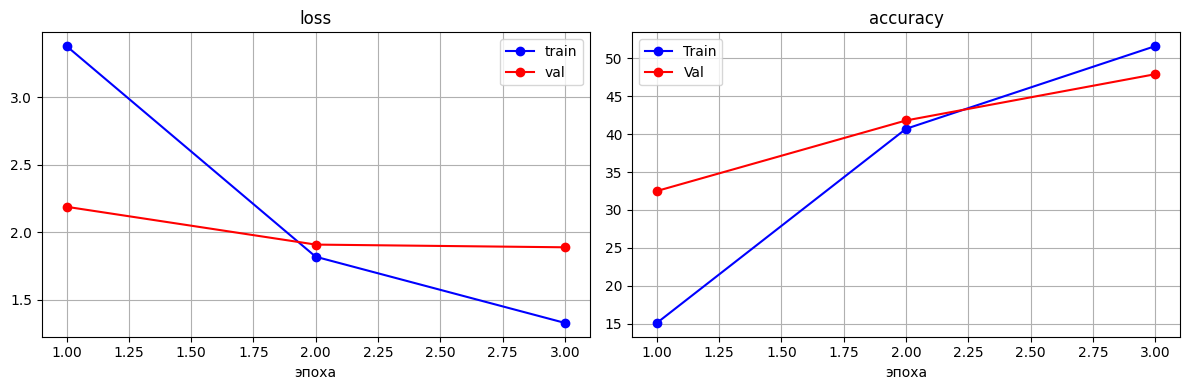

лучшая модель: эпоха 3, val_acc: 47.90%


In [ ]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3]
train_loss = [3.38, 1.82, 1.33]
val_loss = [2.19, 1.91, 1.89]
train_acc = [15.1, 40.7, 51.6]
val_acc = [32.5, 41.8, 47.9]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'b-o', label='train')
plt.plot(epochs, val_loss, 'r-o', label='val')
plt.title('loss')
plt.xlabel('эпоха')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, 'b-o', label='Train')
plt.plot(epochs, val_acc, 'r-o', label='Val')
plt.title('accuracy')
plt.xlabel('эпоха')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
print(f'лучшая модель: эпоха {best_epoch}, val_acc: {best_val_acc:.2f}%')

### Извлечение ответа из контекста
Функция `answer_question()`:
- Токенизирует пару (вопрос, контекст)
- Находит позицию `[SEP]` токена (граница вопроса)
- Ищет start/end токены только в контексте (после `[SEP]`)
- Возвращает ответ как строку

In [ ]:
model_bert.load_state_dict(torch.load('best_qa_model.pth'))
model_bert.eval()

def answer_question(question, context):
    inputs=tokenizer(question, context, max_length=384,
                      truncation='only_second', return_tensors='pt').to(device)

    sep_positions=(inputs['input_ids'][0]==tokenizer.sep_token_id).nonzero()
    question_end=sep_positions[0].item()

    with torch.no_grad():
        outputs = model_bert(**inputs)

    start_i=torch.argmax(outputs.start_logits[0, question_end+1:]) + question_end + 1
    end_i=torch.argmax(outputs.end_logits[0, question_end+1:]) + question_end + 1

    if end_i<start_i:
        start_i, end_i=end_i, start_i

    tokens=tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    answer=tokenizer.convert_tokens_to_string(tokens[start_i:end_i+1])

    return answer

test_list=[
    ("what is the capital of France?",
     "Paris is the capital of France.",
     "paris"),
    ("where is the Eiffel Tower?",
     "The Eiffel Tower is located in Paris.",
     "paris"),
    ("what is the name of Harry Potter's house?",
     "Harry Potter studied at Hogwarts. He was in Gryffindor house.",
     "gryffindor"),
    ("what type of group is XG?",
     "XG is a musical group based in Soth Korea.",
     "musical group")
]

for question, context, expected in test_list:
    answer = answer_question(question, context)
    print(f"вопрос: {question}")
    print(f"ответ: {answer}")
    print(f"ожидалось: {expected}")
    print("верно" if expected.lower() in answer.lower() else "неверно")
    print()

вопрос: what is the capital of France?
ответ: paris
ожидалось: paris
верно

вопрос: where is the Eiffel Tower?
ответ: paris
ожидалось: paris
верно

вопрос: what is the name of Harry Potter's house?
ответ: gryffindor house
ожидалось: gryffindor
верно

вопрос: what type of group is XG?
ответ: musical group based in soth korea
ожидалось: musical group
верно

